# Notebook 7: Explainable AI (XAI) -- LIME e Surrogate Fitting

## Corso: Big Data Analytics
## Università degli studi di Milano - Bicocca
## Corso di Laurea: Economia, Analisi dei Dati e Management

---

### Introduzione

Nei notebook precedenti abbiamo costruito modelli di Machine Learning per classificare testi (es. la sentiment analysis con BoW e TF-IDF nel Notebook 3). I modelli funzionano e ci danno predizioni, ma...

**...come facciamo a capire PERCHÉ un modello prende una certa decisione?**

In questo notebook esploreremo la **Explainable AI (XAI)** e in particolare due approcci complementari:
- **LIME** (Local Interpretable Model-agnostic Explanations) -- per spiegazioni *locali* (singole predizioni)
- **Surrogate Fitting (globale)** -- per spiegazioni *globali* (l'intero modello), tramite un white-box che emula il black-box

Useremo lo **stesso classificatore di sentiment analysis** (TF-IDF + Logistic Regression sulle `movie_reviews`) per entrambi gli approcci, in modo da confrontare direttamente cosa dicono le due tecniche sullo stesso modello.


## 1.1 Cos'è l'Explainable AI (XAI)?

L'**Explainable AI** è il ramo dell'AI che si occupa di **rendere comprensibili** le decisioni dei modelli di Machine/Deep Learning agli esseri umani.

### Perché serve?

I modelli moderni (Deep Learning, Random Forest, Gradient Boosting, BERT, GPT...) sono **black box**: producono predizioni accurate, ma sono molto difficili da interpretare.

| Tipo di Modello | Esempi | Interpretabilità | Performance |
| :--- | :--- | :---: | :---: |
| **White Box** | Regressione Lineare, Decision Tree | ✅ Alta | ❌ Limitata |
| **Black Box** | Random Forest, Reti Neurali, BERT, GPT | ❌ Bassa | ✅ Alta |

### Il dilemma trasparenza vs accuratezza

Spesso esiste un **trade-off**: più il modello è performante, più è difficile capire perché fa una certa predizione.

L'XAI cerca di **rompere questo trade-off**: ottenere modelli accurati MA al tempo stesso interpretabili (almeno *a posteriori*).


## 1.2 Quando ci servono spiegazioni?

L'XAI non è un capriccio accademico. È una necessità pratica in molti contesti reali (i cosiddetti **mission critical domains**):

- **🏥 Sanità**: se un modello predice che un paziente ha una certa patologia, il medico vuole sapere PERCHÉ prima di prescrivere una terapia.
- **🏦 Finanza**: se la banca rifiuta un mutuo, deve spiegare il motivo per legge (GDPR, regolamenti antidiscriminazione).
- **⚖️ Giustizia**: i sistemi di valutazione del rischio di recidiva DEVONO essere trasparenti.
- **🚗 Guida autonoma**: se un'auto a guida autonoma sbaglia, vogliamo sapere perché.
- **🐛 Debugging**: se il modello sbaglia, vogliamo capire perché per migliorarlo.
- **🎯 Bias detection**: scoprire se il modello ha imparato pregiudizi nascosti nei dati.

### Vincoli normativi

L'XAI è anche un requisito **regolatorio**:
- **EU AI Act 2024**: trasparenza, documentazione e human oversight obbligatori per sistemi AI ad alto rischio.
- **GDPR Art. 22**: diritto a una spiegazione delle decisioni automatizzate.
- **Algorithmic Accountability Act 2019** (USA): valutazione dei rischi dei sistemi automatizzati.

> **Esempio reale**: nel 2018 Amazon ha dovuto abbandonare il suo sistema di selezione automatica dei CV perché aveva imparato a discriminare le donne. Senza tecniche di XAI, questo bias sarebbe rimasto invisibile!

# QUALI ALTRI ESEMPI VI VENGONO IN MENTE IN CUI UN MODELLO ACCURATO MA NON SPIEGABILE NON BASTA?


## 2.1 LIME: Local Interpretable Model-agnostic Explanations

**LIME** è uno degli algoritmi di XAI più utilizzati. È stato pubblicato nel 2016 da Ribeiro, Singh e Guestrin nel paper *"Why Should I Trust You?"* e risolve un problema apparentemente impossibile:

> Come spiego le predizioni di un modello complesso (una scatola nera) usando un modello semplice (interpretabile)?

### Decifriamo il nome (acronimo molto denso!)

| Termine | Significato |
| :--- | :--- |
| **L**ocal | Spiega UNA singola predizione, non l'intero modello globalmente |
| **I**nterpretable | Usa un modello semplice (es. regressione lineare sparse) come surrogato |
| **M**odel-agnostic | Funziona con qualsiasi modello (BERT, RandomForest, anche GPT...) |
| **E**xplanations | Produce spiegazioni leggibili (parole evidenziate, feature con pesi) |


## 2.2 L'intuizione: approssimazione locale

L'idea geniale di LIME è semplicissima:

> Un modello complesso può essere **localmente** approssimato da un modello semplice.

### Una metafora

Immaginate la superficie di decisione di un modello come una catena montuosa: a livello globale è curva, frastagliata, irregolare. Ma se zoommate molto su un singolo punto, in un piccolo intorno il terreno sembra **piatto** (lineare).

Allo stesso modo:
- A livello globale, una Random Forest è imprevedibile.
- A livello locale (intorno a una specifica predizione) può essere ben approssimata da una regressione lineare.

LIME impara questa **approssimazione lineare locale** per spiegare la singola predizione, perdendo fedeltà globale ma guadagnando interpretabilità.


## 2.3 Le formule (senza paura!)

L'obiettivo di LIME è trovare una spiegazione $g$ che soddisfi due requisiti contrapposti:
1. Sia **fedele** al modello complesso $f$ nell'intorno locale dell'istanza $x$.
2. Sia **semplice** (e quindi interpretabile per un umano).

### La formula generale

$$\xi(x) \;=\; \arg\min_{g \in G} \; \mathcal{L}\bigl(f, g, \pi_x\bigr) \;+\; \Omega(g)$$

Decifriamola un pezzo alla volta:

- $f$: il modello black box che vogliamo spiegare (es. la nostra Random Forest, BERT, ecc.)
- $x$: l'istanza specifica per cui vogliamo la spiegazione (es. una singola recensione)
- $G$: la famiglia di modelli interpretabili (in pratica regressioni lineari sparse)
- $g$: il modello interpretabile specifico che andremo a scegliere (la spiegazione)
- $\pi_x$: una misura di **prossimità** che dice "quanto un punto perturbato è vicino a $x$"
- $\mathcal{L}(f, g, \pi_x)$: la **fedeltà locale** -- quanto bene $g$ approssima $f$ vicino a $x$
- $\Omega(g)$: la **complessità** di $g$ (es. numero di feature usate -- più $g$ è semplice, meglio è)

### In parole povere

> "Trova il modello semplice $g$ che approssima MEGLIO il modello complesso $f$ nelle vicinanze del punto $x$, mantenendolo il più semplice possibile."

### La fedeltà locale (più nel dettaglio)

$$\mathcal{L}(f, g, \pi_x) \;=\; \sum_{z \in Z} \pi_x(z) \cdot \bigl( f(z) - g(z') \bigr)^2$$

dove:
- $z$ sono **istanze perturbate** intorno a $x$ (testi con parole rimosse, immagini con patch nascoste, ecc.)
- $z'$ è la rappresentazione interpretabile di $z$ (es. presenza/assenza di parole, codificate come $0$/$1$)
- $\pi_x(z) = \exp\!\left(-\dfrac{D(x,z)^2}{\sigma^2}\right)$ è un **kernel gaussiano**: i punti vicini all'istanza originale pesano di più nella loss

In sostanza: stiamo facendo una regressione lineare pesata dove i pesi danno più importanza alle perturbazioni vicine all'input originale.


## 2.4 L'algoritmo passo per passo

Per spiegare una singola predizione, LIME esegue questi passaggi:

1. **Perturbazione**: genera molte versioni perturbate dell'input $x$.
   - **Per il testo**: rimuove casualmente alcune parole (la rappresentazione interpretabile è un vettore binario "parola presente/assente").
   - **Per immagini**: nasconde alcune patch (super-pixel) dell'immagine.
   - **Per dati tabellari**: campiona valori da una distribuzione vicina ai valori originali.

2. **Predizione**: dà ogni versione perturbata in pasto al modello black box $f$ e raccoglie le probabilità predette.

3. **Pesatura**: assegna più peso alle perturbazioni vicine all'input originale (kernel gaussiano $\pi_x$).

4. **Modello surrogato**: addestra un modello semplice (regressione lineare con regolarizzazione Lasso, che spinge molti coefficienti a zero) sui dati perturbati pesati.

5. **Spiegazione**: i coefficienti del modello lineare sono la spiegazione -- mostrano quali feature hanno spinto la predizione **verso** o **contro** la classe predetta.

> **Notate bene**: la spiegazione è **locale**. Le stesse feature potrebbero contare in modo diverso per un'altra istanza! Questo è sia un punto di forza (spiegazioni personalizzate) sia un limite (non ho una visione globale).


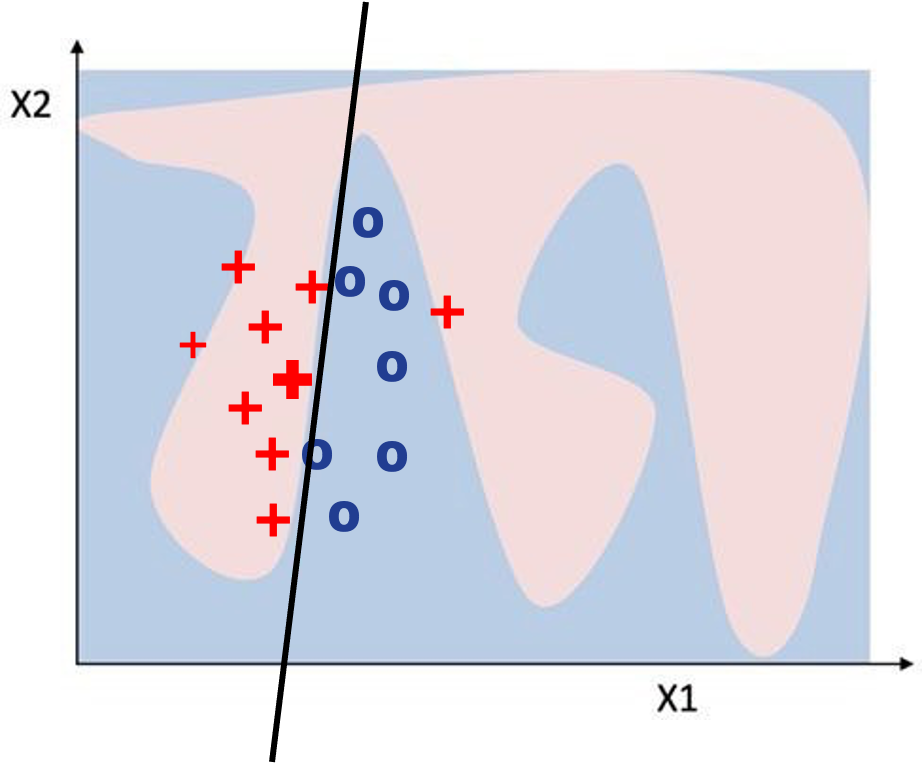

# 🔬 Parte pratica 1: spiegare LOCALMENTE un classificatore di Sentiment Analysis con LIME

Riprendiamo il classificatore di **sentiment analysis** che abbiamo costruito nel Notebook 3 (TF-IDF + Logistic Regression sulle `movie_reviews` di NLTK) e lo rendiamo "interpretabile" usando LIME.

### Il piano:
1. **Setup**: installiamo LIME e carichiamo il dataset
2. **Training**: addestriamo un classificatore di recensioni
3. **Spiegazione**: usiamo LIME per spiegare predizioni specifiche
4. **Insights**: estraiamo insight pratici:
   - Quali parole guidano le predizioni positive/negative?
   - Il modello ha imparato bias o shortcut?
   - Perché certi esempi sono classificati male?
   - Come reagisce a frasi "trabocchetto" (negazioni, sarcasmo)?


In [ ]:
# ==========================================
# 1. INSTALLAZIONE DI LIME
# ==========================================

# LIME non è incluso di default in Colab/Anaconda
# Lo installiamo con pip
# Il "!" è un comando per dire a Colab "esegui questo nel terminale"
!pip install lime --quiet

print("LIME installato correttamente!")


In [ ]:
# ==========================================
# 2. IMPORT E CARICAMENTO DEL DATASET
# ==========================================

import numpy as np
import pandas as pd
import random
import nltk
import matplotlib.pyplot as plt
import re
from nltk.stem import PorterStemmer

# scikit-learn: il classificatore e gli strumenti di vettorizzazione
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report

# LIME: la nostra novità!
# LimeTextExplainer è la classe specifica per spiegare modelli di testo
from lime.lime_text import LimeTextExplainer

# NLTK: per scaricare il dataset di recensioni di film
nltk.download('movie_reviews', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import movie_reviews

# Settiamo i seed per riproducibilità (lo stesso esperimento darà sempre lo stesso risultato)
np.random.seed(42)
random.seed(42)

# ==========================================
# 1. PREPARAZIONE DEL DATASET
# ==========================================

# Scarichiamo le risorse necessarie da NLTK
# movie_reviews: il dataset con 2000 recensioni (1000 pos e 1000 neg)
# stopwords: le parole comuni da filtrare
# punkt: il modello per la tokenizzazione
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('punkt')

# Il dataset di NLTK non è un DataFrame. Dobbiamo iterare sui file 
# per estrarre il testo grezzo e la categoria (pos/neg) associata.
documents = []
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        documents.append({
            'text': movie_reviews.raw(fileid), # Testo completo della recensione
            'sentiment': category              # Etichetta: 'pos' o 'neg'
        })

# Creiamo un DataFrame Pandas per una gestione più agevole dei dati
df = pd.DataFrame(documents)
print(f"Dataset caricato: {df.shape[0]} recensioni.")


In [ ]:
# ==========================================
# 2. PIPELINE DI PREPROCESSING
# ==========================================

# Carichiamo la lista delle stopword inglesi
stop_words = nltk.corpus.stopwords.words('english')
stemmer = PorterStemmer()

def full_preprocessing(text):
    """
    Questa funzione applica a cascata i passaggi visti a lezione.
    """
    # A. Conversione in minuscolo: standardizza i token (Gatto == gatto)
    text = text.lower()
    
    # B. Pulizia Regex: Rimuoviamo punteggiatura, numeri e caratteri speciali
    # Teniamo solo le lettere (a-z) e gli spazi (\s)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # C. Tokenizzazione: Spezziamo la stringa in una lista di parole
    tokens = text.split()
    
    # D. Rimozione Stopwords: Eliminiamo parole come 'the', 'is', 'at' 
    # che non aggiungono valore alla distinzione del sentiment.
    tokens = [w for w in tokens if w not in stop_words]
    
    # E. STEMMING (Novità!)
    # Riduciamo ogni parola alla sua radice
    tokens = [stemmer.stem(w) for w in tokens]

    #ricordati di ablare gli step di preprocessing e mostrare come variano le performance
    # Torniamo una stringa unica (richiesta dai vettorizzatori di Scikit-Learn)
    return " ".join(tokens)

print("Esecuzione del preprocessing in corso...")
# Applichiamo la funzione a tutta la colonna 'text'
df['clean_text'] = df['text'].apply(full_preprocessing)
print("Preprocessing completato.")

In [ ]:
# ==========================================
# 3. SPLIT TRAIN/TEST
# ==========================================

# Split classico 80/20
# stratify=df['sentiment'] mantiene la stessa proporzione di pos/neg in train e test
# random_state=42 garantisce che lo split sia sempre lo stesso
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

print(f"Train set: {len(X_train)} recensioni")
print(f"Test set:  {len(X_test)} recensioni")


In [ ]:
# ==========================================
# 4. TF-IDF + LOGISTIC REGRESSION
# ==========================================

print("\n--- TEST CON TF-IDF ---")

# Inizializziamo il vettorizzatore TF-IDF con le stesse impostazioni
tfidf_vect = TfidfVectorizer(max_features=20000)

# Applichiamo lo stesso processo di prima
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

# Alleniamo un nuovo modello di Regressione Logistica sui pesi TF-IDF
model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, y_train)

# Valutazione
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f"Accuratezza TF-IDF: {acc_tfidf:.4f}")


In [ ]:
# ==========================================
# 5. VALUTAZIONE DEL MODELLO
# ==========================================

y_pred = model_tfidf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuratezza sul test set: {acc:.4f}\n")
print("Report dettagliato (precision, recall, f1):")
print(classification_report(y_test, y_pred))


## 4.1 Costruiamo il LimeTextExplainer

Ora arriva il bello! Usiamo LIME per **spiegare** le predizioni del nostro modello.

L'oggetto chiave è `LimeTextExplainer` (per il testo). Per altri tipi di dati ci sono:
- `LimeTabularExplainer` per dati tabellari (es. dataset Iris, Titanic, ecc.)
- `LimeImageExplainer` per immagini

I principi sono gli stessi, cambia solo il modo di perturbare l'input.


In [ ]:
# ==========================================
# 6. INIZIALIZZAZIONE DELL'EXPLAINER
# ==========================================

# Verifichiamo l'ordine delle classi imparato dal modello
print(f"Ordine classi del modello: {model_tfidf.classes_}")

# bow=True dice a LIME di ignorare l'ordine delle parole (coerente con TF-IDF)
explainer = LimeTextExplainer(
    class_names=model_tfidf.classes_,
    bow=True
)

print("\nExplainer pronto!")


In [ ]:
# ==========================================
# 7. SELEZIONE DI UNA RECENSIONE POSITIVA
# ==========================================

test_reviews = X_test.tolist()
test_labels  = y_test.tolist()
test_preds   = y_pred.tolist()

idx_positiva = 0
for i, (true, pred) in enumerate(zip(test_labels, test_preds)):
    if true == 'pos' and pred == 'pos':
      idx_positiva = i

review_pos = test_reviews[idx_positiva]
review_vector = tfidf_vect.transform([review_pos])
proba_pos  = model_tfidf.predict_proba(review_vector)[0]

print(f"=== RECENSIONE POSITIVA #{idx_positiva} ===")
print(f"Classe vera: pos | Predetta: pos")
print(f"Probabilità predette: neg={proba_pos[0]:.4f}, pos={proba_pos[1]:.4f}")
print(f"\nPrimi 500 caratteri della recensione:\n{review_pos[:500]}...")


In [ ]:
# ==========================================
# 8. GENERIAMO LA SPIEGAZIONE CON LIME
# ==========================================

# explain_instance è il cuore di LIME:
# - text_instance: la recensione da spiegare
# - classifier_fn: la funzione che fa le predizioni (deve restituire probabilità)
# - num_features: quante feature (parole) mostrare nella spiegazione
# - num_samples: quante perturbazioni generare (più sono, più stabile è la spiegazione,
#                ma più tempo ci mette)
#
# ⏳ ATTENZIONE: questa cella può richiedere 30-60 secondi
# perché LIME genera migliaia di varianti perturbate del testo
# e per ognuna fa una predizione con il nostro modello!

predict_fn = lambda x: model_tfidf.predict_proba(tfidf_vect.transform(x))

explanation_pos = explainer.explain_instance(
    text_instance=review_pos,
    classifier_fn=predict_fn,
    num_features=10,
    num_samples=1500
)

print("Spiegazione generata!")


In [ ]:
# ==========================================
# 9. VISUALIZZIAMO LA SPIEGAZIONE
# ==========================================

# .show_in_notebook() è il modo più ricco di visualizzare la spiegazione:
# - A SINISTRA: probabilità predette dal modello
# - AL CENTRO: bar plot delle parole con i loro pesi
#              (verde/blu = a favore della classe positiva,
#               rosso/arancione = contro)
# - A DESTRA: il testo originale con highlighting colorato sulle parole influenti

explanation_pos.show_in_notebook(text=True)


In [ ]:
# ==========================================
# 10. ISPEZIONE NUMERICA DELLA SPIEGAZIONE
# ==========================================

# .as_list() ritorna una lista di tuple (parola, peso)
# - Peso > 0: la parola spinge verso la classe POSITIVA
# - Peso < 0: la parola spinge verso la classe NEGATIVA

print("=== TOP 10 PAROLE PIÙ INFLUENTI ===\n")
print(f"{'PAROLA':<25}{'PESO':>10}    DIREZIONE")
print("-" * 55)
for parola, peso in explanation_pos.as_list():
    direzione = "→ POS" if peso > 0 else "→ NEG"
    print(f"{parola:<25}{peso:>+10.4f}    {direzione}")


### 💡 Cosa abbiamo imparato?

Guardando le parole evidenziate possiamo trarre alcuni **insight**:

- Le parole con **peso positivo** (blu) spingono il modello a predire `pos`
- Le parole con **peso negativo** (arancione) spingono verso `neg`
- Se il modello si basa su parole semanticamente sensate (`great`, `wonderful`, `excellent`...) è un buon segno!
- Se invece troviamo parole "neutrali" tra le top (es. nomi propri, articoli, numeri) è un campanello d'allarme: il modello potrebbe essersi attaccato a feature spurie del dataset (data leakage, shortcut learning).

# DOMANDA: secondo voi quali parole DOVREBBERO comparire come "positive" in una recensione di film? E quali "negative"?


In [ ]:
# ==========================================
# 11. SPIEGHIAMO ANCHE UNA RECENSIONE NEGATIVA
# ==========================================

idx_negativa = 0
for i, (true, pred) in enumerate(zip(test_labels, test_preds)):
    if true == 'neg' and pred == 'neg':
      idx_negativa = i

review_neg = test_reviews[idx_negativa]
review_vector_neg = tfidf_vect.transform([review_neg])
proba_neg  = model_tfidf.predict_proba(review_vector_neg)[0]

print(f"=== RECENSIONE POSITIVA #{idx_negativa} ===")
print(f"Classe vera: pos | Predetta: pos")
print(f"Probabilità predette: neg={proba_neg[0]:.4f}, pos={proba_neg[1]:.4f}")
print(f"\nPrimi 500 caratteri della recensione:\n{review_neg[:500]}...")

explanation_neg = explainer.explain_instance(
    text_instance=review_neg,
    classifier_fn=predict_fn,
    num_features=10,
    num_samples=1500
)

explanation_neg.show_in_notebook(text=True)


## 5. L'insight più potente: capire PERCHÉ il modello SBAGLIA

LIME diventa veramente potente quando lo usiamo per analizzare gli **errori del modello**.

Cerchiamo recensioni che sono state classificate **erroneamente** e vediamo quali parole hanno fuorviato il modello. Questo è uno degli usi più pratici di LIME nella vita di un data scientist:

> "Il mio modello sbaglia su questi 50 esempi. Posso individuare un pattern comune negli errori? Se sì, posso correggerlo."


In [ ]:
# ==========================================
# 12. TROVIAMO UN ESEMPIO MAL CLASSIFICATO
# ==========================================

# Cerchiamo una recensione veramente positiva che il modello ha classificato come negativa
# (un "falso negativo": la recensione è positiva ma il modello la vede come negativa)

idx_errore = 0
for i, (true, pred) in enumerate(zip(test_labels, test_preds)):
    if true == 'pos' and pred == 'neg':
      idx_errore = i

review_errore = test_reviews[idx_errore]
review_vector_errore = tfidf_vect.transform([review_errore])
proba_errore  = model_tfidf.predict_proba(review_vector_errore)[0]

print(f"=== ESEMPIO MAL CLASSIFICATO #{idx_errore} ===")
print(f"Classe vera: pos | Predetta: neg  ❌")
print(f"Probabilità: neg={proba_errore[0]:.4f}, pos={proba_errore[1]:.4f}")
print(f"\nPrimi 600 caratteri:\n{review_errore[:600]}...\n")

explanation_errore = explainer.explain_instance(
    text_instance=review_errore,
    classifier_fn=predict_fn,
    num_features=12,
    num_samples=1500
)

explanation_errore.show_in_notebook(text=True)


### 🐛 Cosa è andato storto?

Guardando la spiegazione possiamo provare a capire **perché** il modello ha sbagliato. Le ipotesi tipiche sono:

- La recensione è **effettivamente ambigua**: contiene critiche specifiche pur essendo nel complesso positiva.
- Il modello si è fissato su parole semanticamente "negative" usate però in **contesto positivo** (negazione, sarcasmo, "non è male", "didn't disappoint").
- Il modello ha imparato **shortcut su feature spurie**: nomi di registi/attori associati a film negativi nel training set, parole che capitano di più nelle recensioni negative ma sono semanticamente neutre, ecc.
- Il **TF-IDF con BoW non cattura il contesto**: per il modello "good" e "not good" sono entrambi solo "good".

Questo tipo di analisi è preziosissimo per:
1. **🔧 Debugging del modello** -- capire e correggere errori sistematici.
2. **🎯 Detection di bias** -- scoprire associazioni indesiderate.
3. **⚠️ Gestione del rischio** -- in applicazioni ad alto impatto (sanità, giustizia, finanza) sapere QUANDO non fidarsi della predizione.


In [ ]:
# ==========================================
# 13. PROBING: TESTIAMO IL MODELLO CON ESEMPI CUSTOM
# ==========================================

frasi_test = [
    "this movie is absolutely amazing, brilliant and wonderful!",       # palesemente positiva
    "this movie is terrible, boring and awful.",                        # palesemente negativa
    "the movie was not bad at all, actually quite enjoyable.",          # NEGAZIONE: è positiva!
    "the movie was great. just kidding, it was awful.",                 # SARCASMO: è negativa
]

print("=== PREDIZIONI DEL MODELLO ===\n")
for frase in frasi_test:
    vector = tfidf_vect.transform([frase])
    proba = model_tfidf.predict_proba(vector)[0]
    pred  = model_tfidf.classes_[np.argmax(proba)]
    print(f"Frase:        '{frase}'")
    print(f"Predizione:   {pred}  (neg={proba[0]:.3f}, pos={proba[1]:.3f})")
    print()


In [ ]:
# ==========================================
# 14. SPIEGAZIONE DI UNA FRASE CON NEGAZIONE
# ==========================================

# Vediamo cosa succede con la frase tricky:
#   "the movie was not bad at all, actually quite enjoyable."
# Questa frase è SEMANTICAMENTE POSITIVA, ma contiene la parola 'bad'.
# Il modello capirà la negazione di "bad"?

frase_tricky = "the movie was not bad at all, actually quite enjoyable."

# Con bigrammi (ngram_range=(1,2)) il modello PUÒ vedere "not bad" come token unico,
# quindi in linea teorica dovrebbe gestirlo. Vediamo se è così!

explanation_tricky = explainer.explain_instance(
    text_instance=frase_tricky,
    classifier_fn=predict_fn,
    num_features=8,
    num_samples=2000
)

print("Spiegazione per:")
print(f"   '{frase_tricky}'\n")
explanation_tricky.show_in_notebook(text=True)


### 🤔 Riflessione: i limiti del Bag-of-Words

Senza usare bigrammi, in una frase come `"the movie was not bad at all"` un classificatore basato su BoW/TF-IDF unigram-only:

- vedrebbe `bad` come token isolato con peso negativo (preso da solo è negativo);
- non capirebbe che la `not` immediatamente precedente lo nega.

Con `ngram_range=(1, 2)` il modello PUÒ trattare `"not bad"` come bigramma unico, ma:
- deve aver visto abbastanza esempi di `"not bad"` nel training set per imparare che è positivo;
- non gestisce ancora costruzioni più complesse come `"the movie was great. just kidding, it was awful."` (sarcasmo).

> **Soluzione**: per gestire negazione complessa e sarcasmo serve passare a modelli **contestuali** (BERT, RoBERTa, modelli LLM) anche se a volte non basta nenache questo

LIME è prezioso proprio perché ci mostra in modo **lampante** dove e perchè il modello sbaglia -- e quindi quando serve cambiare approccio.


# 🌍 Parte pratica 2: spiegare GLOBALMENTE lo STESSO classificatore con Surrogate Fitting

LIME ci ha dato spiegazioni **locali**: per ogni recensione abbiamo capito *quali parole* hanno spinto la predizione del modello in una direzione o nell'altra. Ottimo per ispezionare singoli casi, ma...

> Come si comporta il modello **nel suo complesso**? Esiste un modo per riassumere in poche righe quello che fanno i 20.000 coefficienti del nostro classificatore?

La risposta è il **Surrogate Fitting (globale)**: una tecnica che usa un white-box (Decision Tree, Logistic Regression sparsa) per **emulare** il modello "complesso" e fornirne così una spiegazione globale.

### Perché ci serve, anche per il nostro classificatore TF-IDF + LR?

Per semplificarci la vita lo applichiamo alla nostra Logistic Regression anche se è già trasparente (in fondo, basta leggerne i coefficienti)! Ma:
- Ha **20.000 feature** (parole + bigrammi). Nessun manager leggerà 20.000 coefficienti.
- Vogliamo una **sintesi**: "quali sono i 10-20 pattern globali su cui il modello si basa?"
- Vogliamo poter **confrontare** queste regole globali con le spiegazioni locali di LIME (sanity check).

Il surrogato risponde a questa domanda.


## 6.1 Surrogate Fitting: l'idea

L'idea centrale è semplice e potente:

> Se il mio modello complesso $b$ (Black Box) è troppo opaco da capire, posso allenare un modello semplice $w$ (White Box) che **imita** $b$. Il modello semplice diventa la mia "spiegazione" di $b$.

### Schema concettuale

```
                ┌──────────┐         ┌─────────────┐         ┌─────────────┐
[True labels]──▶│ BLACK BOX│──▶ Predictions ──▶  WHITE BOX ──▶ Predictions
                │          │     + ACCURACY    │ (surrogato) │  + FIDELITY
                └──────────┘                   └─────────────┘
                                                       │
                                                       ▼
                                          ┌────────────────────────┐
                                          │     EXPLANATION        │
                                          │  - Decision tree       │
                                          │  - Logistic regression │
                                          └────────────────────────┘
```



### I 5 step

1. **Black Box training**: ho un BLACK BOX $b$ (la nostra TF-IDF + LR, ma anche RF, NN, ecc.) addestrato con label vere $y$. Misuro la sua **ACCURACY** rispetto a $y$.
2. **BB predictions**: genero le predizioni di $b$ su tutti i dati: $\hat{y}_b = b(X)$.
3. **Surrogate training**: addestro un WHITE BOX $w$ (Decision Tree poco profondo, Logistic Regression sparse) usando $\hat{y}_b$ come label. **NB: NON $y$, ma $\hat{y}_b$!**
4. **Fidelity measurement**: misuro la **FIDELITY** di $w$:
$$\text{Fidelity}(w, b) \;=\; \frac{1}{|X|}\sum_{x \in X} \mathbb{1}\bigl[w(x) = b(x)\bigr]$$
5. **Explanation extraction**: il modello $w$ -- visualizzabile (albero) o leggibile (coefficienti) -- è la **spiegazione globale** di $b$.

### Le formule

**Formulazione classica** (Burkart & Huber, 2021), come problema di **minimizzazione del disaccordo**:

$$w^* \;=\; \arg\min_{w \in I} \;\frac{1}{|X|}\sum_{x \in X} S\bigl(w(x),\, b(x)\bigr)$$

dove $I$ è la famiglia di modelli interpretabili, $S$ è una misura di "distanza" tra le predizioni dei due modelli e $X$ è l'insieme di dati.

**Formulazione equivalente con vincolo di complessità** (Malandri et al., ContrXT 2022):

$$p_g^* \;=\; \arg\max_{p_g \in I} \;\frac{1}{|X|}\sum_{x \in X} S\bigl(p_g(x),\, \psi(x)\bigr) \qquad \text{s.t.} \quad \Omega(p_g) \le \Gamma$$

dove $\psi$ è il black box, $S$ è la fidelity (questa volta come **similarità** da MASSIMIZZARE), $\Omega$ è una misura di complessità del modello surrogato (numero di nodi foglia di un albero, numero di coefficienti non-zero in una regressione) e $\Gamma$ è un upper bound che fissiamo per garantire l'interpretabilità.

### ACCURACY vs FIDELITY: la distinzione cruciale ⚠️

| Metrica | Cosa misura | A cosa serve |
| :--- | :--- | :--- |
| **Accuracy** del black box ($b$ vs $y$) | Quanto il BB azzecca le label vere | Performance del modello |
| **Fidelity** del surrogato ($w$ vs $b$) | Quanto $w$ imita $b$ | Qualità della **spiegazione** |

> **Attenzione**: una fidelity alta NON significa che il modello sia accurato! Significa che la spiegazione è fedele al modello. Se il BB sbaglia, il surrogato (e quindi la spiegazione) "spiegherà fedelmente" anche gli errori. Sono due numeri **diversi** che misurano cose diverse.


## 6.2 Caso pratico: spiegare globalmente il classificatore TF-IDF + LR

Applichiamo il Surrogate Fitting al **classificatore TF-IDF + Logistic Regression** che abbiamo già allenato sulle `movie_reviews` (Parte 1). Stesso dataset, stesso modello.

Lo trattiamo come un **Black Box** e gli affianchiamo:
1. Un **Decision Tree** poco profondo come surrogato → ci darà *regole if-then* su singole parole.
2. Una **Logistic Regression sparsa** (Lasso) come surrogato alternativo → ci darà una *lista compatta* di parole positive/negative.

Il pay-off didattico: confronteremo le **parole globalmente importanti** secondo il surrogato con le **parole localmente importanti** che LIME ci aveva mostrato per le singole recensioni.


In [ ]:
# ==========================================
# STEP 1: ALLENIAMO IL WHITE BOX SURROGATO (Decision Tree)
# ==========================================
# BLACK BOX predictions  →  WHITE BOX  →  Predictions + FIDELITY

from sklearn.tree import DecisionTreeClassifier

# Vettorizziamo train e test usando lo STESSO TF-IDF della pipeline
# (fondamentale: il surrogato deve "vedere" gli stessi input del BB)
X_train_vec = X_train_tfidf
X_test_vec  = X_test_tfidf

# IDEA CHIAVE: il surrogato NON impara dalle label vere y_train,
# ma dalle PREDIZIONI del Black Box!
y_train_bb = model_tfidf.predict(X_train)
y_test_bb  = model_tfidf.predict(X_test)

# Surrogato = Decision Tree con profondità LIMITATA
# Limitiamo la complessità → vincolo Omega(w) <= Gamma della formula
# Qui: max_depth=4 → al più 16 foglie, leggibile a colpo d'occhio
surrogate_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

print("Addestramento del surrogato (Decision Tree)...")
print("NOTA IMPORTANTE: usiamo le predizioni del BLACK BOX come label, NON le label vere y!\n")
surrogate_tree.fit(X_train_vec, y_train_bb)

# FIDELITY: quanto il surrogato imita il Black Box?
y_test_surr = surrogate_tree.predict(X_test_vec)
fidelity_tree = accuracy_score(y_test_bb, y_test_surr)

# Per riferimento: accuracy del surrogato sulle label VERE
acc_surr_true = accuracy_score(y_test, y_test_surr)

print(f">>> FIDELITY del surrogato (vs Black Box): {fidelity_tree:.4f}")
print(f"    (quanto il surrogato IMITA il BLACK BOX → qualità della spiegazione)")
print(f"\n>>> Accuracy del surrogato sulle label vere: {acc_surr_true:.4f}")
print(f"    (più bassa: il modello semplice è meno preciso, ma spiega bene il BLACK BOX)")
print(f"\n>>> Accuracy del Black Box: {acc_bb_test:.4f}  (per confronto)")


In [ ]:
# ==========================================
# STEP 2: LA SPIEGAZIONE GLOBALE = LA STRUTTURA DELL'ALBERO
# ==========================================
# Explanation: Decision Tree (regole if-then sulle parole)

# Visualizzando l'albero stiamo letteralmente "guardando dentro" la spiegazione
# del Black Box. Ogni cammino radice→foglia è una REGOLA IF-THEN su parole.

from sklearn.tree import plot_tree

feature_names = model_tfidf.get_feature_names_out()

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    surrogate_tree,
    feature_names=feature_names,
    class_names=['neg', 'pos'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,    # togliamo 'gini' per non affollare i nodi
    proportion=True,   # mostriamo proporzioni invece di conteggi
)
plt.title(
    f"Surrogato globale: Decision Tree che imita TF-IDF + LR\n"
    f"Fidelity = {fidelity_tree:.3f}",
    fontsize=14
)
plt.tight_layout()
plt.show()

print(f"\nNumero di foglie del surrogato: {surrogate_tree.get_n_leaves()}")
print(f"Profondità massima:              {surrogate_tree.get_depth()}")


### 💡 Cosa ci dice l'albero surrogato?

Ogni split dell'albero è del tipo:

> *"se la parola/bigramma X ha TF-IDF > soglia, allora vai a destra; altrimenti a sinistra."*

In pratica, il singolo split corrisponde a "la parola compare in modo prominente nel testo, sì o no". Questo ci dà delle **regole if-then leggibili** su quali combinazioni di parole spingono il modello verso `pos` o `neg`.

### Cosa guardare nell'albero:
- **La feature alla radice** è la **più importante a livello globale** (lo split che riduce di più l'incertezza).
- **Le foglie colorate** indicano la classe predetta dal BLACK BOX per quel sottogruppo.
- I percorsi radice → foglia sono le **regole globali** del modello.

Estraiamo ora il ranking numerico delle feature.


In [ ]:
# ==========================================
# 18. RANKING NUMERICO DELLE FEATURE (dal Decision Tree surrogato)
# ==========================================

# Le feature usate dall'albero (importanza > 0)
imp = pd.Series(surrogate_tree.feature_importances_, index=feature_names)
top_words_tree = imp[imp > 0].sort_values(ascending=False)

print(f"=== TOP-{len(top_words_tree)} PAROLE GLOBALMENTE IMPORTANTI (Decision Tree) ===\n")
print(f"{'PAROLA / BIGRAMMA':<35}{'IMPORTANZA':>12}")
print("-" * 50)
for word, val in top_words_tree.items():
    bar = "█" * int(val * 60)
    print(f"{word:<35}{val:>12.3f}  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(top_words_tree))))
top_words_tree[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importanza globale (Decision Tree surrogato)')
ax.set_title('Parole globalmente più importanti per il classificatore di sentiment')
plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# 19. SURROGATO ALTERNATIVO: LOGISTIC REGRESSION SPARSE (L1)
# ==========================================
# Stesso schema, ma con un white box di natura diversa: una regressione
# logistica con regolarizzazione L1 (Lasso), che spinge molti coefficienti
# a zero → sparsità → interpretabilità.

surrogate_lr = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1,             # C basso = regolarizzazione forte = surrogato più sparso
    max_iter=1000,
    random_state=42
)

print("Addestramento del surrogato (Logistic Regression sparse)...")
surrogate_lr.fit(X_train_vec, y_train_bb)   # NB: di nuovo y_train_bb, non y_train!

# FIDELITY del nuovo surrogato
fidelity_lr = surrogate_lr.score(X_test_vec, y_test_bb)
n_nonzero = (surrogate_lr.coef_[0] != 0).sum()

print(f"\n>>> FIDELITY del surrogato LR (vs BLACK BOX): {fidelity_lr:.4f}")
print(f">>> Coefficienti non-zero: {n_nonzero:,}/{n_features:,}")
print(f"    Riduzione: il surrogato usa solo il {100*n_nonzero/n_features:.1f}% delle feature originali!")

# Top parole positive e negative globalmente
coefs = pd.Series(surrogate_lr.coef_[0], index=feature_names)
top_pos = coefs.nlargest(10)
top_neg = coefs.nsmallest(10)

print("\n=== TOP-10 PAROLE → 'pos' (globalmente) ===")
print(f"{'PAROLA / BIGRAMMA':<30}{'COEF':>8}")
print("-" * 40)
for w, c in top_pos.items():
    print(f"{w:<30}{c:>+8.3f}")

print("\n=== TOP-10 PAROLE → 'neg' (globalmente) ===")
print(f"{'PAROLA / BIGRAMMA':<30}{'COEF':>8}")
print("-" * 40)
for w, c in top_neg.items():
    print(f"{w:<30}{c:>+8.3f}")


In [ ]:
# ==========================================
# 20. VISUALIZZAZIONE TOP PAROLE GLOBALI (LR surrogato)
# ==========================================

# Mettiamo insieme top-pos e top-neg in un'unica visualizzazione
all_top = pd.concat([top_neg.iloc[::-1], top_pos.iloc[::-1]])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['salmon' if c > 0 else 'steelblue' for c in all_top]
all_top.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficiente (positivo → pos, negativo → neg)')
ax.set_title('Parole globalmente più associate a recensioni positive/negative\n(Surrogato Logistic Regression L1)')
plt.tight_layout()
plt.show()


### 💡 Sintesi: cosa ci dice il surrogato sul nostro modello?

Sia il Decision Tree sia la Logistic Regression sparsa concordano su un set ristretto di parole/bigrammi che governano globalmente le predizioni del classificatore. Tipicamente emergono:

- Parole semanticamente positive che spingono verso `pos` (`great`, `wonderful`, `excellent`, ...)
- Parole semanticamente negative che spingono verso `neg` (`bad`, `worst`, `boring`, `awful`, ...)
- Eventuali pattern non-banali: bigrammi come `not bad` (se presenti nel training), o nomi di persone/registi se il modello ha imparato shortcut.

### 🤝 Confronto con le spiegazioni LIME (locali)

Riprendiamo la recensione positiva spiegata con LIME nella Parte 1: le parole che LIME aveva evidenziato come "spinge verso pos" dovrebbero comparire (almeno in parte) anche nel ranking globale del surrogato.

**Questo confronto è utilissimo**:
- Se le top-parole locali (LIME) sono nelle top-parole globali (Surrogate) → il modello è coerente.
- Se LIME mette in cima parole che il surrogato non vede mai globalmente → quella predizione si basa su un caso particolare (forse un'eccezione, forse un errore).


In [ ]:
# ==========================================
# 21. CONFRONTO LIME (locale) vs SURROGATO (globale)
# ==========================================
# Sanity check: le parole che LIME giudica importanti per UNA recensione
# sono anche tra quelle globalmente importanti secondo il surrogato?

# Top parole secondo LIME (locale, per la recensione positiva della Parte 1)
top_lime_words = [w for w, _ in explanation_pos.as_list()]

# Top parole globali secondo il surrogato LR (positive + negative)
top_global_words = pd.concat([top_pos, top_neg]).index.tolist()

# Overlap
overlap = set(top_lime_words) & set(top_global_words)

print(f"Top-10 parole secondo LIME (locale, recensione #{idx_positiva}):")
for w in top_lime_words:
    marker = "  ← anche TOP GLOBALE" if w in top_global_words else ""
    print(f"  • {w}{marker}")

print(f"\nSovrapposizione tra top-LIME (locale) e top-LR (globale): {len(overlap)}/{len(top_lime_words)} parole")
if overlap:
    print(f"Parole comuni: {sorted(overlap)}")


### 🔑 La regola d'oro

| | **Surrogate Fitting (globale)** | **LIME (locale)** |
| :--- | :--- | :--- |
| Cosa spiega | TUTTO il modello | UNA sola predizione |
| Output | Albero / coefficienti pesati | Pesi delle feature per quell'istanza |
| Quando usarlo | Audit, debug sistematico, business insight, regulatory | Spiegare al cliente "perché QUESTA decisione" |
| Metrica chiave | **Fidelity** (vs BB) | Fedeltà locale (kernel pesato) |
| Vincolo di interpretabilità | $\Omega(w) \le \Gamma$ esplicito | Implicito (numero di feature) |

> **Best practice in produzione**: usare ENTRAMBI. Surrogato globale per capire il modello a livello sistematico (audit interno, report al management); LIME locale per giustificare singole decisioni a utenti finali e clienti.


# 📝 Pseudocodice: dal pensiero al codice

Prima di chiudere, formalizziamo i due workflow XAI in **pseudocodice**, in linea con quanto visto nel **Notebook 6**.

> Lo pseudocodice è un linguaggio intermedio tra l'italiano e il codice Python: descrive la logica passo-passo, indipendentemente dal linguaggio di programmazione e dalle librerie. È utile per **progettare** un programma prima di scriverlo, e per **comunicare** la logica a chi non conosce Python.

I vantaggi:
- Ti permette di concentrarti sulla **logica**, non sulla sintassi.
- È **universale**: chiunque può capirlo (anche un manager o un domain expert).
- Riduce drasticamente gli errori quando scriverai il codice vero.


## 7.1 Pseudocodice: spiegazione LOCALE con LIME (testo)

### Vediamo come descriveremmo il workflow visto nella Parte 1 del notebook.


In [ ]:
INIZIO
    CARICA dataset_testi (es. movie_reviews di NLTK)

    # 1. Preparazione e training del modello black box
    DIVIDI il dataset in:
        - DATI_ADDESTRAMENTO (80%)
        - DATI_TEST (20%)

    TRASFORMO DATI_ADDESTRAMENTO in vettori usando TF-IDF
    TRAINING del CLASSIFICATORE (es. Logistic Regression) su su DATI_ADDESTRAMENTO
    TEST del CLASSIFICATORE su DATI_TEST → punteggio_accuratezza

    # 2. Inizializzazione dell'explainer LIME
    CREA LimeTextExplainer con i nomi delle classi (es. ['neg', 'pos'])

    # 3. Spiegazione locale di una singola istanza
    SCEGLI un'istanza x dal DATI_TEST (es. una recensione)

    SPIEGA l'istanza x usando LIME
FINE


## 8. Riepilogo: pro e contro di LIME e Surrogate Fitting

### LIME ✅ Vantaggi
- **Model-agnostic**: funziona con qualunque modello (anche GPT-4, BERT, modelli proprietari).
- **Interpretazioni intuitive**: parole evidenziate, facili da spiegare anche a stakeholder non tecnici.
- **Versatile**: testo, immagini, dati tabellari -- stesso framework concettuale.
- **Risposta diretta** alla domanda "perché QUESTA predizione?"

### LIME ⚠️ Limiti
- **Stabilità**: le perturbazioni casuali possono dare risultati leggermente diversi tra run.
- **Solo locale**: una spiegazione per UNA istanza, non per il modello globale.
- **Costo computazionale**: ogni spiegazione richiede migliaia di chiamate al modello.
- **Approssimazione lineare**: se l'intorno locale è molto non-lineare, perde fedeltà.

### Surrogate Fitting (globale) ✅ Vantaggi
- **Visione d'insieme**: una spiegazione che copre TUTTO il modello.
- **Garanzia matematica**: la fidelity è quantificabile in modo esplicito.
- **Output umani**: regole if-then (Decision Tree) o coefficienti pesati (Regressione).
- **Audit-ready**: perfetto per regolatori, manager, audit interni.
- **Metric trasparente**: la distinzione **FIDELITY vs ACCURACY** misura esplicitamente la qualità della spiegazione, separata dalla performance del modello.

### Surrogate Fitting ⚠️ Limiti
- **Trade-off complessità/fedeltà**: surrogato troppo semplice → bassa fidelity; troppo complesso → non interpretabile (è il senso del vincolo $\Omega(p_g) \le \Gamma$).
- **Solo globale**: non spiega le singole istanze (per quello serve LIME).
- **Sensibile al dataset**: se cambia la distribuzione degli input cambia la spiegazione (data drift).

### Quando usare cosa?

| Scenario | Tecnica | Perché |
| :--- | :--- | :--- |
| Spiegare a un cliente perché un mutuo è stato negato | LIME | Spiegazione locale specifica di quel caso |
| Audit del modello da parte del regulator | Surrogate Fitting | Vista globale del comportamento |
| Debug del modello su esempi mal classificati | LIME | Identifica feature spurie su quel singolo errore |
| Capire i driver di business globali | Surrogate Fitting | Regole if-then leggibili dal management |
| Testare ipotesi su un singolo input artificiale | LIME | Probing locale |
| Reporting periodico al CdA | Surrogate Fitting | Sintetizza il modello in un grafico/regole |

### Altre tecniche di XAI da conoscere
| Tecnica | Idea principale | Quando usarla |
| :--- | :--- | :--- |
| **SHAP** | Valori di Shapley dalla teoria dei giochi | Quando serve coerenza locale-globale e garanzie teoriche |
| **Anchors** | Regole "if-then" sufficienti per la predizione | Quando vuoi regole esplicite per un'istanza |
| **Integrated Gradients** | Gradient-based, per reti neurali | Quando hai accesso ai gradienti |
| **Attention** | Pesi di attenzione (in Transformer) | Per modelli come BERT/GPT |
| **Counterfactuals** | "Cosa cambierebbe se modificassi X?" | Per scenari "what-if" |
| **ContrXT** | Spiegazioni contrastive di classificatori testuali | Per confrontare modelli o classi |
